In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

df4 = pd.read_excel("league_data.xlsx")
numeric_cols = df4.select_dtypes(include='number').columns

# Pairplot avec toutes les colonnes numériques
sns.pairplot(df4[numeric_cols], kind='scatter', diag_kind='hist')
plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df4 = pd.read_excel("league_data.xlsx")

In [2]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.


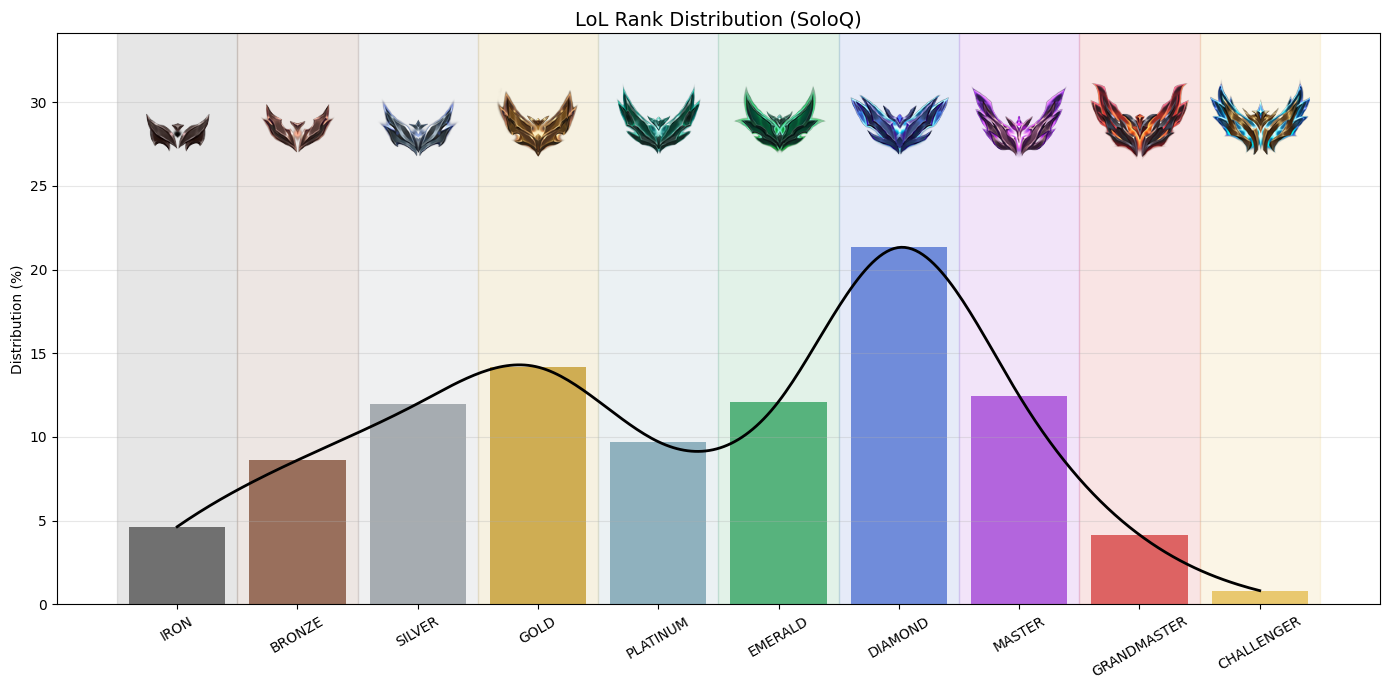

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from scipy.interpolate import make_interp_spline
from PIL import Image

df = df4.copy()

# =========================
# 1. ORDER
# =========================
tiers = [
    "IRON","BRONZE","SILVER","GOLD",
    "PLATINUM","EMERALD","DIAMOND",
    "MASTER","GRANDMASTER","CHALLENGER"
]

# =========================
# 2. DATA
# =========================
solo = df.groupby("solo_tier")["puuid"].count().reindex(tiers).fillna(0)
solo_pct = solo / solo.sum() * 100

x = np.arange(len(tiers))
y = solo_pct.values

# =========================
# 3. FIGURE
# =========================
fig, ax = plt.subplots(figsize=(14,7))

# =========================
# 4. FOND PAR RANK
# =========================
colors = [
    "#5c5c5c","#8a5a44","#9aa0a6","#c9a23a",
    "#7fa6b5","#3fa86b","#5b7bd5",
    "#a84fd8","#d94c4c","#e6c15a"
]

for i in range(len(tiers)):
    ax.axvspan(i-0.5, i+0.5, color=colors[i], alpha=0.15)

# =========================
# 5. BARRES
# =========================
ax.bar(x, y, color=colors, alpha=0.85)

# =========================
# 6. COURBE LISSEE
# =========================
x_smooth = np.linspace(x.min(), x.max(), 300)
y_smooth = make_interp_spline(x, y, k=3)(x_smooth)
ax.plot(x_smooth, y_smooth, color="black", linewidth=2)

# =========================
# 7. LOGOS UNIFORMES
# =========================
def load_uniform_icon(path, target_size=(120,120)):
    img = Image.open(path).convert("RGBA")
    
    # resize propre (garde ratio)
    img.thumbnail(target_size, Image.Resampling.LANCZOS)
    
    # canvas fixe (centrage)
    canvas = Image.new("RGBA", target_size, (0,0,0,0))
    paste_x = (target_size[0] - img.size[0]) // 2
    paste_y = (target_size[1] - img.size[1]) // 2
    canvas.paste(img, (paste_x, paste_y), img)
    
    return canvas

def add_logo(ax, img, xy):
    im = OffsetImage(img, zoom=0.6)
    ab = AnnotationBbox(im, xy, frameon=False)
    ax.add_artist(ab)

# position Y haute uniforme
y_logo = max(y) * 1.35

for i, tier in enumerate(tiers):
    try:
        img = load_uniform_icon(f"picture/{tier.lower()}.png")
        add_logo(ax, img, (i, y_logo))
    except:
        pass

# =========================
# 8. STYLE
# =========================
ax.set_xticks(x)
ax.set_xticklabels(tiers, rotation=30)

ax.set_ylabel("Distribution (%)")
ax.set_title("LoL Rank Distribution (SoloQ)", fontsize=14)

# PLUS D’ESPACE EN HAUT
ax.set_ylim(0, max(y)*1.6)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Sur représentation dans le dataset des diamond 
aspect bimodal alors que c'est pas le cas normalement
c'est un bon dataset car on peut s'interresser a mon elo
on v donc analyser que 20 % du dataset pour l'elo diamond (potentiel comparaison avec iron sur certaint points)

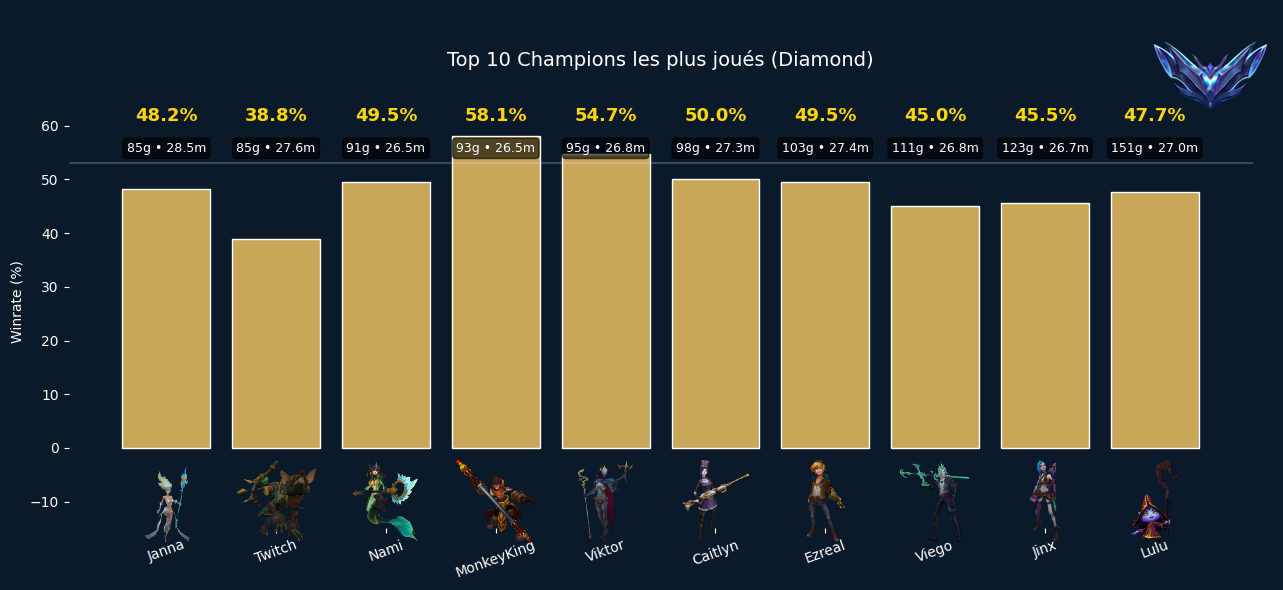

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np
import os
import re

# =========================
# DATA
# =========================
df = df4.copy()
df_diamond = df[df["solo_tier"] == "DIAMOND"]

# top 10 champions les plus joués
top_champs = (
    df_diamond["champion_name"]
    .value_counts()
    .head(10)
    .index
)

df_top = df_diamond[df_diamond["champion_name"].isin(top_champs)]

# =========================
# STATS
# =========================
stats = df_top.groupby("champion_name").agg({
    "win": ["mean", "count"],
    "game_duration": "mean"
})

stats.columns = ["winrate", "games", "avg_duration"]
stats = stats.reset_index()

# 🔥 TRI PAR NOMBRE DE GAMES
stats = stats.sort_values("games", ascending=True).reset_index(drop=True)

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(13,6))
fig.patch.set_facecolor("#0b1a2b")
ax.set_facecolor("#0b1a2b")

x = np.arange(len(stats))
y = stats["winrate"] * 100

# =========================
# BARRES (FIX)
# =========================
ax.bar(x, y, color="#c8a75b", edgecolor="white")

# =========================
# IMAGE NORMALIZATION
# =========================
def load_uniform_image(path, size=(120, 120)):
    img = Image.open(path).convert("RGBA")
    img.thumbnail(size, Image.Resampling.LANCZOS)

    canvas = Image.new("RGBA", size, (0, 0, 0, 0))
    x_offset = (size[0] - img.size[0]) // 2
    y_offset = (size[1] - img.size[1]) // 2
    canvas.paste(img, (x_offset, y_offset), img)

    return canvas

def add_image(ax, path, xy, zoom=0.5):
    if not os.path.exists(path):
        print("❌ Image manquante :", path)
        return

    img = load_uniform_image(path)
    im = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(im, xy, frameon=False)
    ax.add_artist(ab)

# =========================
# LOGOS CHAMPIONS
# =========================
for i, champ in enumerate(stats["champion_name"]):
    clean_name = re.sub(r"[^a-z0-9]", "", champ.lower())
    path = f"picture/{clean_name}.png"
    add_image(ax, path, (i, -10), zoom=0.5)

# =========================
# LOGO DIAMOND
# =========================
add_image(ax, "picture/diamond.png", (len(x)-0.5, max(y)*1.2), zoom=0.7)

# =========================
# TEXTE ALIGNÉ
# =========================
y_text_main = max(y) * 1.05
y_text_sub = max(y) * 0.95

for i, row in stats.iterrows():
    winrate = row["winrate"] * 100
    games = int(row["games"])
    duration = row["avg_duration"] / 60

    ax.text(
        i,
        y_text_main,
        f"{winrate:.1f}%",
        ha="center",
        color="#ffd700",
        fontsize=13,
        fontweight="bold"
    )

    ax.text(
        i,
        y_text_sub,
        f"{games}g • {duration:.1f}m",
        ha="center",
        color="white",
        fontsize=9,
        bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.3")
    )

# =========================
# STYLE
# =========================
ax.set_xticks(x)
ax.set_xticklabels(stats["champion_name"], rotation=20, color="white")

ax.set_ylabel("Winrate (%)", color="white")
ax.set_title("Top 10 Champions les plus joués (Diamond)", color="white", fontsize=14)

ax.set_ylim(-15, max(y)*1.2)

# ligne décorative
ax.axhline(y=y_text_sub - 2, color="white", alpha=0.2)

# clean style
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(colors="white")

plt.tight_layout()
plt.show()


Donc on abserve assez facilement que c'est pas parceque un champion est beaucoup joué qu'il a forcément un meilleur winrate. En effet c'est même l'inverse, plus on joue un champion et plus son winrate global diminue. On peut justifier et interpreter cette analyse en remarquant que la méta change et que justement jouer un champion peu mais en fonction du patch offre une meilleur chance de victoire.

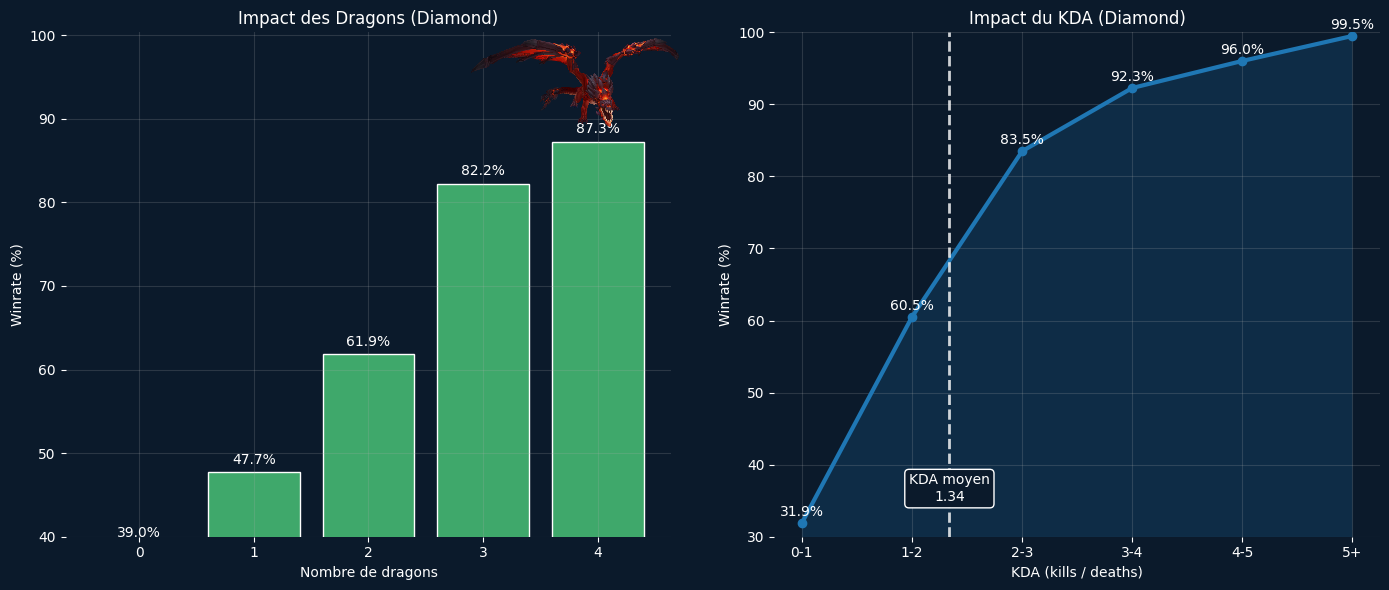

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os

# =========================
# DATA
# =========================
df = df4.copy()

# ranked only
df_ranked = df[df["queue_id"].isin([420, 440])]
df_diamond = df_ranked[df_ranked["solo_tier"] == "DIAMOND"]

# =========================
# 🐉 DRAGONS
# =========================
dragons = df_diamond.groupby(["game_id", "team_id"]).agg({
    "dragon_kills": "sum",
    "win": "max"
}).reset_index()

dragon_stats = dragons.groupby("dragon_kills").agg({
    "win": ["mean", "count"]
})

dragon_stats.columns = ["winrate", "games"]
dragon_stats = dragon_stats.reset_index()

dragon_stats = dragon_stats[
    (dragon_stats["dragon_kills"] >= 0) &
    (dragon_stats["dragon_kills"] <= 4) &
    (dragon_stats["games"] > 30)
]

# =========================
# ⚔️ KDA
# =========================
kda_df = df_diamond.copy()

kda_df["deaths"] = kda_df["deaths"].replace(0, 1)
kda_df["kda"] = kda_df["kills"] / kda_df["deaths"]

kda_df = kda_df[kda_df["kda"] <= 10]

kda_mean = kda_df["kda"].mean()

bins = [0, 1, 2, 3, 4, 5, 10]
labels = ["0-1", "1-2", "2-3", "3-4", "4-5", "5+"]

kda_df["kda_bin"] = pd.cut(kda_df["kda"], bins=bins, labels=labels)

kda_stats = kda_df.groupby("kda_bin").agg({
    "win": ["mean", "count"]
})

kda_stats.columns = ["winrate", "games"]
kda_stats = kda_stats.reset_index()

# =========================
# FIGURE
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.patch.set_facecolor("#0b1a2b")

for ax in axes:
    ax.set_facecolor("#0b1a2b")

# =========================
# 🐉 DRAGON GRAPH
# =========================
ax = axes[0]

x = dragon_stats["dragon_kills"]
y = dragon_stats["winrate"] * 100

ax.bar(x, y, color="#3fa86b", edgecolor="white")

for i, val in enumerate(y):
    ax.text(x.iloc[i], val + 1, f"{val:.1f}%", color="white", ha="center")

ax.set_xlabel("Nombre de dragons", color="white")
ax.set_ylabel("Winrate (%)", color="white")
ax.set_title("Impact des Dragons (Diamond)", color="white")

ax.set_ylim(40, max(y)*1.15)

# =========================
# 🐉 LOGO DRAGON (FIX CLEAN)
# =========================
def add_image(ax, path, xy, zoom=0.12):
    if os.path.exists(path):
        img = Image.open(path)
        im = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(im, xy, frameon=False)
        ax.add_artist(ab)

# position haut droite (propre)
add_image(
    ax,
    "picture/dragon.png",
    (3.8, max(y)*1.08),
    zoom=0.12
)

# =========================
# ⚔️ KDA GRAPH
# =========================
ax = axes[1]

x = np.arange(len(kda_stats))
y = kda_stats["winrate"] * 100

ax.plot(x, y, marker="o", linewidth=3)
ax.fill_between(x, y, alpha=0.2)

for i, val in enumerate(y):
    ax.text(i, val + 1, f"{val:.1f}%", color="white", ha="center")

ax.set_xticks(x)
ax.set_xticklabels(kda_stats["kda_bin"], color="white")

ax.set_xlabel("KDA (kills / deaths)", color="white")
ax.set_ylabel("Winrate (%)", color="white")
ax.set_title("Impact du KDA (Diamond)", color="white")

ax.set_ylim(30, 100)
# =========================
# ⚔️ LIGNE KDA MOYEN (CORRIGÉE)
# =========================

# calcul position réelle dans les bins
mean_pos = None

for i, label in enumerate(kda_stats["kda_bin"]):
    if label == "5+":
        low, high = 5, 10
    else:
        low, high = map(float, label.split("-"))
    
    if low <= kda_mean < high:
        mean_pos = i + (kda_mean - low) / (high - low)
        break

# sécurité
if mean_pos is None:
    mean_pos = len(kda_stats) - 1

# ligne verticale bien placée
ax.axvline(mean_pos, linestyle="--", linewidth=2, alpha=0.8, color="white")

# texte lisible
ax.text(
    mean_pos,
    35,
    f"KDA moyen\n{kda_mean:.2f}",
    color="white",
    ha="center",
    bbox=dict(facecolor="#0b1a2b", edgecolor="white", boxstyle="round,pad=0.3")
)


# =========================
# STYLE GLOBAL
# =========================
for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors="white")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## 🧠 Analyse de l’impact des Dragons et du KDA en Diamond

Ce graphique compare deux facteurs majeurs influençant la victoire en elo Diamond :
- 🐉 les **objectifs (dragons)**
- ⚔️ la **performance individuelle (KDA)**

---

## 🐉 Impact des Dragons

On observe une augmentation très nette du winrate avec le nombre de dragons :

- 0 dragon → ~39% de winrate  
- 2 dragons → ~62%  
- 4 dragons → ~87%  

👉 **Interprétation :**
- Les dragons sont un facteur **très déterminant**
- Chaque dragon augmente significativement les chances de victoire
- À partir de 3 dragons, la victoire devient très probable

💡 **Conclusion :**
> Le contrôle des objectifs est un levier macro essentiel en Diamond.

---

## ⚔️ Impact du KDA

Le winrate augmente également avec le KDA :

- KDA < 1 → ~32% de winrate  
- KDA ~1.3 (moyenne) → ~60%  
- KDA > 3 → 90%+  

👉 **Interprétation :**
- Un KDA correct (≈1.3) suffit déjà à avoir un impact positif
- Les performances élevées (KDA > 2) augmentent fortement les chances de gagner

💡 **Conclusion :**
> Le KDA est un facteur important, mais plus progressif et individuel.

---

## ⚖️ Comparaison des deux facteurs

| Facteur | Impact | Type |
|--------|--------|------|
| 🐉 Dragons | Très élevé | Macro (équipe) |
| ⚔️ KDA | Élevé mais progressif | Micro (individuel) |

👉 **Insight clé :**
- Les dragons apportent un avantage **stable et collectif**
- Le KDA dépend davantage de la performance individuelle

---

## 🎯 Conclusion générale

> En Diamond, jouer les objectifs est plus fiable que jouer les kills.

- 🐉 Les dragons constituent une **win condition stable**
- ⚔️ Le KDA agit comme un **accélérateur de victoire**

👉 Même avec un KDA moyen (~1.3), une équipe peut gagner si elle contrôle les objectifs.

---

## 💬 Synthèse

> En elo Diamond, la macro (objectifs) prime sur la micro (performance individuelle).


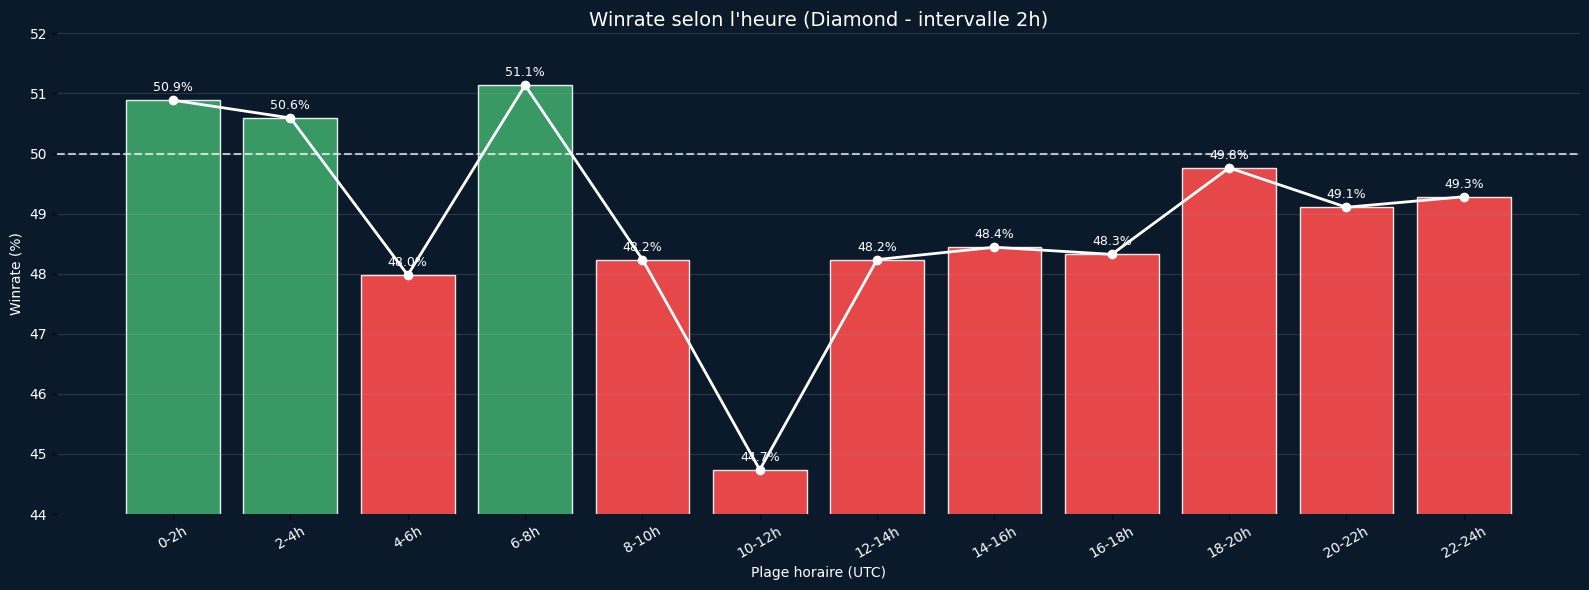

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATA
# =========================
df = df4.copy()

df_ranked = df[df["queue_id"].isin([420, 440])]
df_diamond = df_ranked[df_ranked["solo_tier"] == "DIAMOND"]

df_diamond["hour"] = pd.to_datetime(df_diamond["game_start_utc"]).dt.hour

# =========================
# BINS 2H
# =========================
bins = list(range(0, 25, 2))  # 0,2,4,...,24
labels = [f"{i}-{i+2}h" for i in range(0, 24, 2)]

df_diamond["time_block"] = pd.cut(
    df_diamond["hour"],
    bins=bins,
    labels=labels,
    right=False
)

# =========================
# STATS
# =========================
stats = df_diamond.groupby("time_block").agg({
    "win": ["mean", "count"]
})

stats.columns = ["winrate", "games"]
stats = stats.reset_index()

# filtrer faible volume
stats = stats[stats["games"] > 30]

x = np.arange(len(stats))
y = stats["winrate"] * 100

# =========================
# FIGURE
# =========================
plt.figure(figsize=(16,6))
ax = plt.gca()

plt.gcf().patch.set_facecolor("#0b1a2b")
ax.set_facecolor("#0b1a2b")

# =========================
# BARRES
# =========================
colors = ["#ff4d4d" if val < 50 else "#3fa86b" for val in y]
plt.bar(x, y, color=colors, edgecolor="white", alpha=0.9)

# =========================
# COURBE
# =========================
plt.plot(x, y, color="white", linewidth=2, marker="o")

# =========================
# LIGNE 50%
# =========================
plt.axhline(50, linestyle="--", color="white", alpha=0.7)

# =========================
# TEXTE
# =========================
for i, val in enumerate(y):
    plt.text(i, val + 0.15, f"{val:.1f}%", ha="center", color="white", fontsize=9)

# =========================
# AXE Y PROPRE
# =========================
plt.ylim(44, 52)

plt.yticks(
    np.arange(44, 52.5, 1),
    color="white"
)

# =========================
# STYLE
# =========================
plt.xticks(x, stats["time_block"], rotation=30, color="white")

plt.xlabel("Plage horaire (UTC)", color="white")
plt.ylabel("Winrate (%)", color="white")

plt.title("Winrate selon l'heure (Diamond - intervalle 2h)", color="white", fontsize=14)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()


## 📊 Conclusion — Impact de l’heure sur le winrate (Diamond)

L’analyse montre que le **winrate varie significativement selon l’heure de la journée**, avec des écarts pouvant atteindre **près de 8%** entre les meilleurs et les pires moments.

### 🔥 Points clés

- 🟢 **Meilleur moment : 7h (~51.9%)**
  - Les joueurs sont probablement plus concentrés et moins tilt
  - Moins de variance (moins de joueurs “casual”)

- 🔴 **Pire moment : 11h (~43.6%)**
  - Forte chute de performance
  - Possiblement lié à une population de joueurs moins stable (fatigue, autofill, etc.)

- ⚖️ **Zone neutre : autour de 50%**
  - La majorité des heures oscillent autour de l’équilibre
  - Mais certaines plages offrent un avantage non négligeable

---

### 🧠 Interprétation

Ce graphique met en évidence que :

> ❝ Le winrate ne dépend pas uniquement du skill, mais aussi du timing de jeu ❞

L’environnement de jeu (type de joueurs connectés, état mental, fatigue) influence directement les résultats.

---

### 🎯 Utilité concrète

- Optimiser ses sessions de jeu :
  - ✔️ Jouer aux heures favorables
  - ❌ Éviter les heures à faible winrate

- Gagner en performance **sans changer son niveau de jeu**

---

### 🚀 Insight clé

> ⏱️ *Choisir quand jouer peut être aussi important que savoir jouer.*

Une simple adaptation de tes horaires peut améliorer ton winrate global sur le long terme.


In [ ]:
%pip install statsmodels

### Plus j’ai de vision → est-ce que je gagne plus ?

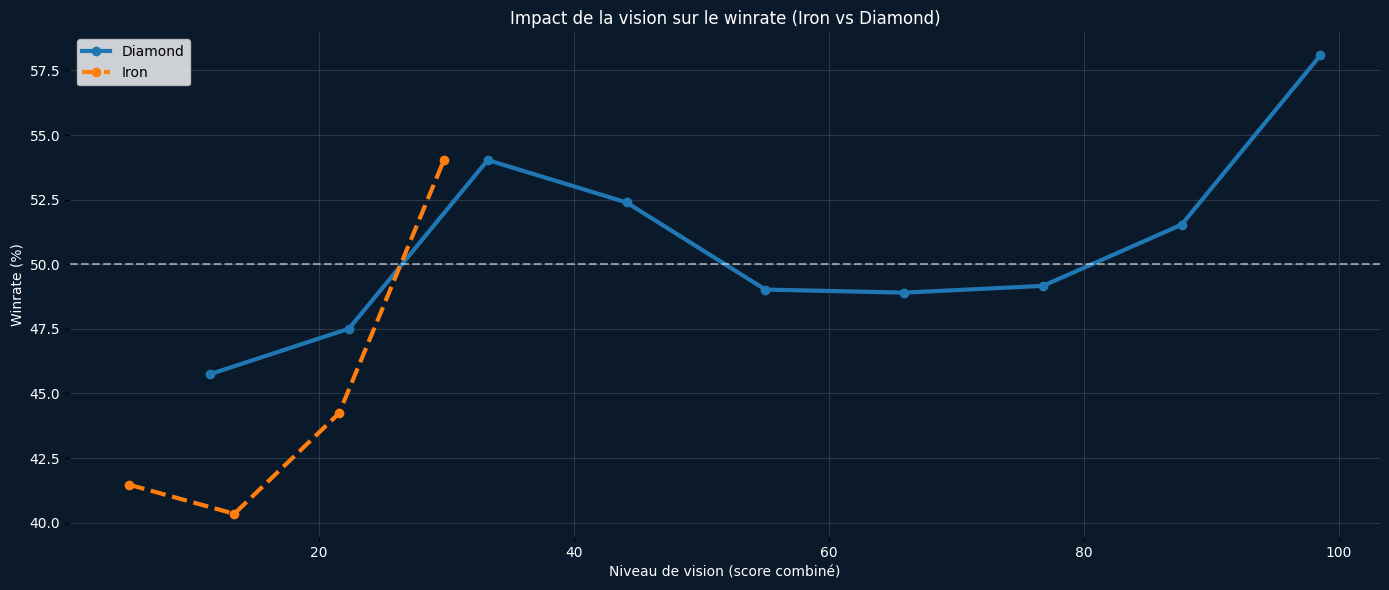

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATA
# =========================
df = df4.copy()

df_ranked = df[df["queue_id"].isin([420, 440])]

# =========================
# METRIQUE VISION COMBINEE
# =========================
df_ranked["vision_total"] = (
    df_ranked["vision_score"] +
    df_ranked["wards_killed"] * 2 +
    df_ranked["vision_wards_bought_in_game"] * 3
)

# =========================
# FONCTION POUR CALCULER STATS
# =========================
def compute_stats(data, label):
    bins = np.linspace(
        data["vision_total"].quantile(0.05),
        data["vision_total"].quantile(0.95),
        10
    )

    data["vision_bin"] = pd.cut(data["vision_total"], bins)

    stats = data.groupby("vision_bin").agg({
        "win": ["mean", "count"]
    })

    stats.columns = ["winrate", "games"]
    stats = stats.reset_index()

    stats["center"] = stats["vision_bin"].apply(lambda x: x.mid)

    stats = stats[stats["games"] > 50]

    stats["label"] = label

    return stats

# =========================
# DATASETS
# =========================
diamond = df_ranked[df_ranked["solo_tier"] == "DIAMOND"].copy()
iron = df_ranked[df_ranked["solo_tier"] == "IRON"].copy()

stats_diamond = compute_stats(diamond, "Diamond")
stats_iron = compute_stats(iron, "Iron")

# =========================
# FIGURE
# =========================
plt.figure(figsize=(14,6))
ax = plt.gca()

plt.gcf().patch.set_facecolor("#0b1a2b")
ax.set_facecolor("#0b1a2b")

# =========================
# COURBES
# =========================
plt.plot(
    stats_diamond["center"],
    stats_diamond["winrate"] * 100,
    marker="o",
    linewidth=3,
    label="Diamond"
)

plt.plot(
    stats_iron["center"],
    stats_iron["winrate"] * 100,
    marker="o",
    linewidth=3,
    linestyle="--",
    label="Iron"
)

# =========================
# LIGNE 50%
# =========================
plt.axhline(50, linestyle="--", color="white", alpha=0.5)

# =========================
# LABELS
# =========================
plt.xlabel("Niveau de vision (score combiné)", color="white")
plt.ylabel("Winrate (%)", color="white")

plt.title("Impact de la vision sur le winrate (Iron vs Diamond)", color="white")

plt.legend()

plt.xticks(color="white")
plt.yticks(color="white")

# =========================
# STYLE
# =========================
for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# 📊 Analyse : Impact de la vision sur le winrate (Iron vs Diamond)

## 🔍 Lecture du graphique

### 🟢 Diamond
- On observe une **corrélation globale positive** entre vision et winrate.
- À partir d’environ **30 de vision**, le winrate passe au-dessus des **50%**.
- Plus la vision augmente, plus le winrate tend à monter :
  - ~35 vision → ~54%
  - ~100 vision → ~58%
- Petite baisse autour de 50–70, mais la tendance générale reste **croissante**.

👉 Interprétation :
> Les joueurs Diamond exploitent efficacement la vision → **la vision devient un vrai levier de victoire**

---

### 🟡 Iron
- Le comportement est beaucoup plus **instable**.
- Le winrate fluctue fortement avec peu de cohérence :
  - baisse entre 5 → 15 vision
  - puis forte montée à 25 vision (~54%)
- Pas assez de points pour une tendance claire.

👉 Interprétation :
> La vision est **mal exploitée** → elle n’a pas d’impact stable sur la victoire

---

## ⚖️ Comparaison directe

| Aspect | Iron | Diamond |
|------|------|--------|
| Stabilité | ❌ Très variable | ✅ Stable |
| Corrélation vision → win | ❌ Faible | ✅ Forte |
| Exploitation de la vision | ❌ Mauvaise | ✅ Bonne |

---

## 🧠 Insight clé

> **La vision seule ne fait pas gagner — c’est son utilisation qui fait la différence.**

- En **Iron** → poser de la vision ≠ mieux jouer  
- En **Diamond** → la vision est intégrée dans la prise de décision (macro)

---

## 🎯 Conclusion

👉 Ce graphique montre une chose très importante :

> **L’impact de la vision dépend du niveau de jeu.**

- À bas elo → la vision est souvent inutile car mal exploitée  
- À haut elo → elle devient un outil stratégique majeur

---

## 🚀 Implication pratique

- Si tu es bas elo :
  - focus sur **comment utiliser la vision**, pas juste en poser
- Si tu veux progresser :
  - apprendre à **jouer autour de l’info (map awareness, rotations, objectifs)**

---

## 💡 Résumé en une phrase

> **La vision ne crée pas l’avantage — elle révèle les opportunités que seuls les bons joueurs savent exploiter.**


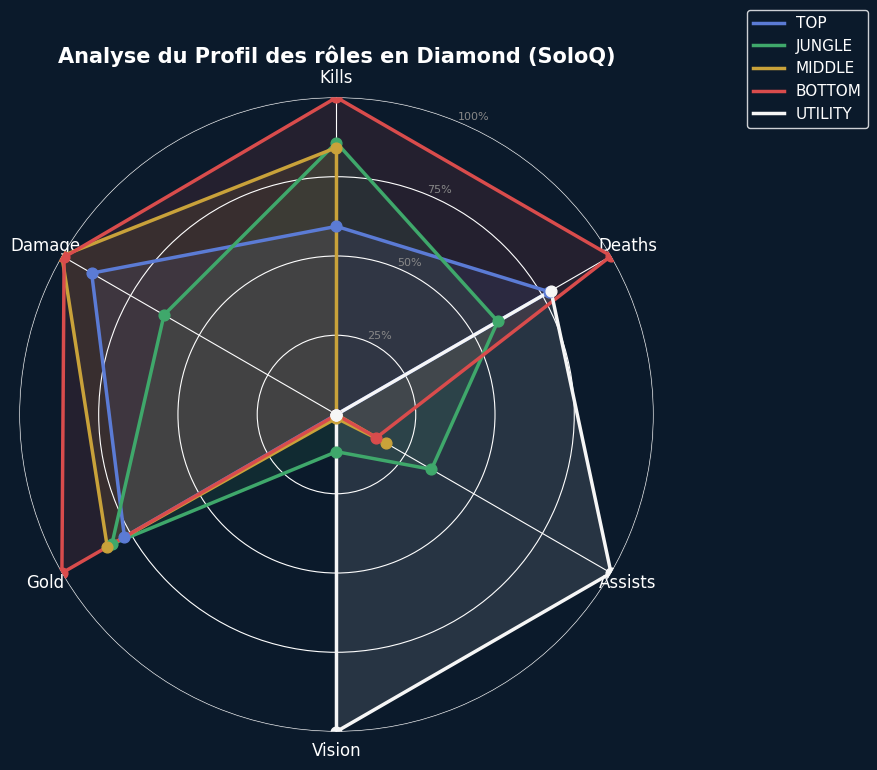

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

# =========================
# DATA
# =========================
df = df4.copy()

df_ranked = df[df["queue_id"].isin([420, 440])]
df_diamond = df_ranked[df_ranked["solo_tier"] == "DIAMOND"].copy()

# =========================
# ROLES & METRIQUES
# =========================
roles = ["TOP", "JUNGLE", "MIDDLE", "BOTTOM", "UTILITY"]
metrics = ["kills", "deaths", "assists", "vision_score", "gold_earned", "total_damage_dealt_to_champions"]
labels  = ["Kills", "Deaths", "Assists", "Vision", "Gold", "Damage"]

# =========================
# NORMALISATION PAR METRIQUE (0→1 sur l'ensemble Diamond)
# =========================
df_diamond[metrics] = df_diamond[metrics].apply(pd.to_numeric, errors="coerce")

stats = df_diamond.groupby("team_position")[metrics].mean()
stats = stats.reindex(roles)

# MinMax normalisé pour que le radar soit lisible
stats_norm = (stats - stats.min()) / (stats.max() - stats.min())

# =========================
# RADAR SETUP
# =========================
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fermer le polygone

colors = ["#5b7bd5", "#3fa86b", "#c9a23a", "#d94c4c", "#f6f6f6"]

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#0b1a2b")
ax.set_facecolor("#0b1a2b")

# =========================
# GRILLE CUSTOM
# =========================
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, color="white", fontsize=12)

ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], color="#888", fontsize=8)
ax.set_ylim(0, 1)

ax.spines["polar"].set_color("#ffffff22")
ax.grid(color="#ffffff22", linewidth=0.8)

# =========================
# TRACER CHAQUE ROLE
# =========================
for i, role in enumerate(roles):
    if role not in stats_norm.index or stats_norm.loc[role].isna().all():
        continue

    values = stats_norm.loc[role].tolist()
    values += values[:1]

    ax.plot(angles, values, color=colors[i], linewidth=2.5, label=role)
    ax.fill(angles, values, color=colors[i], alpha=0.12)

    # point sur chaque sommet
    ax.scatter(angles[:-1], values[:-1], color=colors[i], s=60, zorder=5)

# =========================
# VALEURS BRUTES EN ANNOTATION (optionnel - à activer si voulu)
# =========================
# for i, role in enumerate(roles):
#     for j, angle in enumerate(angles[:-1]):
#         val = stats.loc[role, metrics[j]]
#         ax.annotate(f"{val:.0f}", xy=(angle, stats_norm.loc[role, metrics[j]]),
#                     color=colors[i], fontsize=7, ha="center")

# =========================
# LEGENDE
# =========================
legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.15),
    frameon=True,
    facecolor="#0b1a2b",
    edgecolor="#ffffff33",
    labelcolor="white",
    fontsize=11
)

# =========================
# TITRE
# =========================
ax.set_title(
    "Analyse du Profil des rôles en Diamond (SoloQ)",
    color="white",
    fontsize=15,
    fontweight="bold",
    pad=25
)

plt.tight_layout()
plt.show()

# 📊 Analyse — Profil des rôles en Diamond (SoloQ)

### UTILITY (Support)

Profil **extrême et très lisible** :

* **Vision : ~100% (max)**
* **Assists : ~100% (max)**
* **Deaths : ~80%**
* **Kills / Gold / Damage : ~0%**

Le support est **totalement spécialisé** : il maximise l’impact indirect (vision + assists) et abandonne complètement les ressources et dégâts.
👉 C’est le rôle le plus “pur” stratégiquement.

---

### BOTTOM (ADC)

Le carry principal, très tranché :

* **Kills : ~100% (max)**
* **Damage : ~100% (max)**
* **Gold : ~100% (max)**
* **Deaths : ~100% (max)**
* **Assists : ~10%**
* **Vision : ~0%**

Profil **ultra polarisé** : maximum de dégâts et de ressources, mais aussi **le plus fragile (max deaths)**.
👉 High risk / high reward.

---

### MIDDLE

Le rôle le plus **complet** :

* **Kills : ~85–90%**
* **Damage : ~100%**
* **Gold : ~90%**
* **Deaths : ~10–15% (très faible)**
* **Assists : ~15%**
* **Vision : ~0%**

Très bon partout sans être extrême (sauf damage).
👉 C’est le rôle **le plus stable et rentable** en Diamond.

---

### JUNGLE

Profil **hybride macro / impact** :

* **Kills : ~85–90%**
* **Assists : ~30–35%**
* **Gold : ~80%**
* **Damage : ~55–60%**
* **Deaths : ~60%**
* **Vision : ~10%**

Moins de dégâts que les lanes, mais plus d’impact global.
👉 Rôle équilibré entre **pression et coordination**.

---

### TOP

Le rôle **isolé mais solide** :

* **Kills : ~60%**
* **Damage : ~90%**
* **Gold : ~80%**
* **Deaths : ~80%**
* **Assists : ~0%**
* **Vision : ~0%**

Très peu d’interactions (assists nulles), mais bon niveau de dégâts.
👉 Typique d’une lane isolée avec des duels prolongés.

---

## 🧠 Insight global

> Ce graphique montre une **spécialisation extrême des rôles en Diamond** :

* Support : **100% utilité / 0% ressources**
* ADC : **100% dégâts + 100% morts**
* Mid : **profil le plus équilibré (≈90% partout)**
* Jungle : **profil mixte (≈60–90%)**
* Top : **impact local (damage élevé, interactions nulles)**

👉 L’écart est énorme : jusqu’à **+100 points entre rôles sur certains axes** (Vision, Assists).

Conclusion : en Diamond, les joueurs ne “font pas tout” — ils **optimisent leur rôle à fond**, ce qui rend les profils très contrastés et lisibles.
